# earthkit-geo

In this notebook you will see how to:

- inspect the grid properties of GRIB data
- plot the gridpoints of a field
- interpolate GRIB data from one grid to another (regridding)
- extract the nearest gridpoint from a field
- obtain polygons suitable for a polytope request

### 1. Getting the data

The input data is a GRIB file containing 1000 hPa temperature fields on 3 different global grids. 

First, fetch the file and list its contents.

In [1]:
import earthkit.data as ekd

ds = ekd.from_source("sample", "grids_3.grib").to_fieldlist()

ds.ls()

grids_3.grib:   0%|          | 0.00/33.0k [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2015-04-22 12:00:00,2015-04-22 12:00:00,0 days,1000,pressure,None,regular_ll
1,t,2015-04-22 12:00:00,2015-04-22 12:00:00,0 days,1000,pressure,None,reduced_gg
2,t,2015-04-22 12:00:00,2015-04-22 12:00:00,0 days,1000,pressure,None,healpix


### 2. Select a field
Next, select the field you will inspect in the rest of the notebook.

To try another grid type, change the field index below and rerun the subsequent cells of the notebook.

In [2]:
# take one field
print("Possible indexes:", 0, 'to', len(ds)-1)
field_index = 0
f = ds[field_index]
f

Possible indexes: 0 to 2


number_of_values,2664
array_type,ndarray
array_dtype,float64
variable,t
standard_name,air_temperature
long_name,Temperature
units,kelvin
chem_variable,None
valid_datetime,2015-04-22 12:00:00
base_datetime,2015-04-22 12:00:00
step,0:00:00


### 2. Inspecting the grid

With the `geography` metadata component, you can inspect all the relevant geographical metadata.

In [3]:
f.geography.grid_type()

'regular_ll'

Inspect the 'grid_spec' - this is a canonical description of the grid used to identify it.
See https://earthkit-geo.readthedocs.io/en/latest/concepts/regridding/mir/gridspec.html for more details of this.

In [4]:
f.geography.grid_spec()

{'grid': [5, 5]}

The field's shape is derived from the geography. For grids with  regular 2D structure, like regular latitude-longitude grids, the shape is always 2D. Otherwise, like for reduced Gaussian grids, it is 1D.

In [5]:
f.geography.shape()

(37, 72)

### 3. Plotting the gridpoints

This example shows you how to plot the original gridpoint positions of the field.

In [6]:
import earthkit.plots as ekp

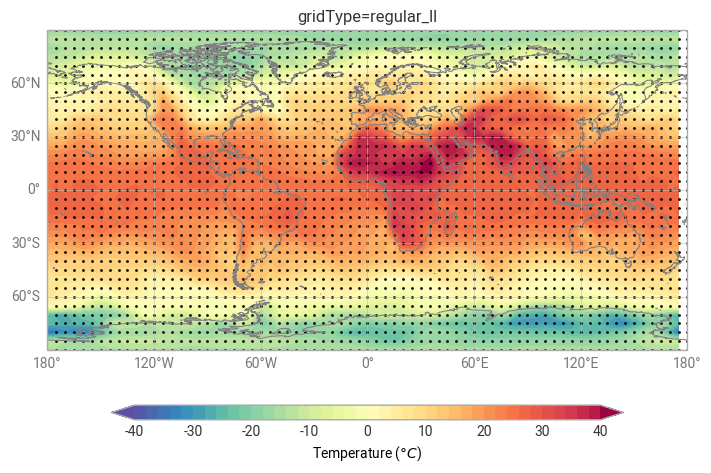

In [7]:
chart = ekp.Map(size=(7,7))
chart.contourf(f, units="celsius", auto_style=True)

# plot the original grid points
chart.grid_points(f, c="black")

chart.title(f"gridType={f.geography.grid_type()}")
chart.coastlines(color="grey")
chart.gridlines()
chart.legend()

chart.show()

### 4. Regridding

You can regrid data with [earthkit.geo.regrid()](https://earthkit-geo.readthedocs.io/en/release-1.0.0rc0/guide/mir/regrid_high.html). This uses ECMWF's MIR library to perform the regridding computations. The first time that a new combination of input and output grid is encountered, you may see some extra output logs, and the processing may take a few seconds. Subsequent regriddings with those grids will be faster, as they will use cached interpolation matrices.


In [8]:
import earthkit.geo as ekg

In [9]:
# the target grid is a global 10x10 degree regular latitude-longitude grid
out_grid = {"grid": [10,10]}

# XX exercise: if you are currently on the 3rd field, i.e. HEALPix, look at the grid_spec printed above, and generate an 'H8' grid
# by creating and using a new grid_spec which is a modification of it
# out_grid = {'grid': 'H8', 'order': 'nested'}

# perform interpolation to produce a new field
f_res = ekg.regrid(f, grid=out_grid, interpolation="linear")

# XX exercise: print out the grid_spec of the resultant data
print(f_res.geography.grid_spec())

{'grid': [10, 10]}


The next cell plots the original and interpolated fields over a subarea.

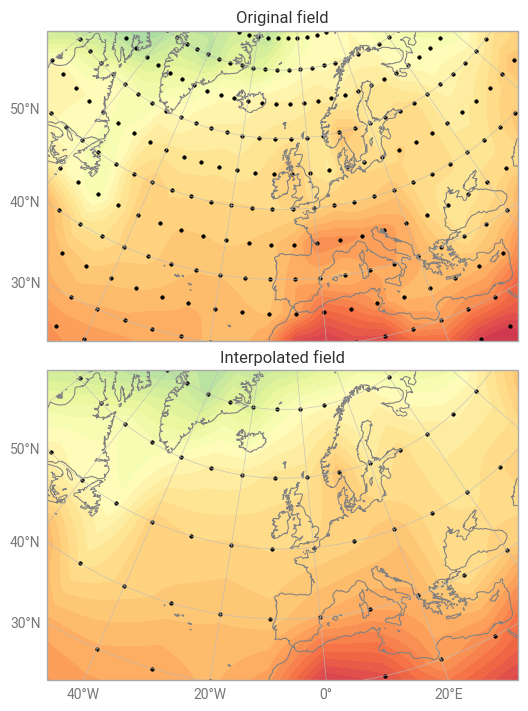

In [10]:
figure = ekp.Figure(domain="North Atlantic", rows=2, columns=1)

# the original field
subplot = figure.add_map(0, 0)
subplot.contourf(f, units="celsius", auto_style=True)
subplot.grid_points(f, c="black", s=25)
subplot.title("Original field")

# the interpolated field
subplot = figure.add_map(1, 0)
subplot.contourf(f_res, units="celsius", auto_style=True)
subplot.grid_points(f_res, c="black", s=25)
subplot.title("Interpolated field")

figure.coastlines(color="grey")
figure.gridlines()

figure.show()

### 5. Getting the nearest gridpoint

In this example you can see how to extract the nearest gridpoint value of a field using [earthkit.geo.nearest_point_haversine()](https://earthkit-geo.readthedocs.io/en/latest/autoapi/earthkit/geo/distance/nearest_point_haversine.html#earthkit.geo.distance.nearest_point_haversine).

In [11]:
# ref location (lat, lon)
p_ref = (51.45, -0.97)

# get latlon
latlon = f.geography.latlons()
lat = latlon[0]
lon = latlon[1]

# get nearest point index
idx, dist = ekg.distance.nearest_point_haversine(p_ref, (lat, lon))
idx

array([576])

In [12]:
# extract field value at given index
f.values[idx]

array([283.45458984])

### Goto 2
Now go back to part 2 of this notebook, increase the field index and re-run the code up to this point

### 6. Working with NetCDF data

It is more natural to work with NetCDF data in xarray representation, which Earthkit also supports.

In [13]:
# download some example NetCDF data and read into an xarray
fs = ekd.from_source("sample", "era5-hourly-2t-20230724T1200Z.nc")
f = fs.to_xarray()
t2 = f["t2m"]
t2

era5-hourly-2t-20230724T1200Z.nc:   0%|          | 0.00/1.99M [00:00<?, ?B/s]

<xarray.DataArray 't2m' (time: 1, latitude: 721, longitude: 1440)> Size: 8MB
[1038240 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 8B 2023-07-24T12:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    units:      K
    long_name:  2 metre temperature

In [14]:
# note that although Eathkit in the future will be able to derive the grid_spec from an xarray, it is currently
# required to explicitly supply this information. From looking at the metadata above, we can see that the xarray
# is a regular 0.25-degree grid, so we add a grid_spec attribute to annotate the DataArray with this information
t2.attrs["ek_grid_spec"] = '{"grid": [0.25, 0.25]}'
t2

<xarray.DataArray 't2m' (time: 1, latitude: 721, longitude: 1440)> Size: 8MB
[1038240 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 8B 2023-07-24T12:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    units:         K
    long_name:     2 metre temperature
    ek_grid_spec:  {"grid": [0.25, 0.25]}

In [15]:
# the target grid is a global 10x10 degree regular latitude-longitude grid
out_grid = {"grid": [10,10]}

# perform interpolation
f_res = ekg.regrid(t2, grid=out_grid)
f_res

<xarray.DataArray 't2m' (time: 1, latitude: 19, longitude: 36)> Size: 5kB
array([[[273.5982498 , 273.5982498 , 273.5982498 , 273.5982498 ,
         273.5982498 , 273.5982498 , 273.5982498 , 273.5982498 ,
         273.5982498 , 273.5982498 , 273.5982498 , 273.5982498 ,
         273.5982498 , 273.5982498 , 273.5982498 , 273.5982498 ,
         273.5982498 , 273.5982498 , 273.5982498 , 273.5982498 ,
         273.5982498 , 273.5982498 , 273.5982498 , 273.5982498 ,
         273.5982498 , 273.5982498 , 273.5982498 , 273.5982498 ,
         273.5982498 , 273.5982498 , 273.5982498 , 273.5982498 ,
         273.5982498 , 273.5982498 , 273.5982498 , 273.5982498 ],
        [274.06905172, 277.2738412 , 275.70573715, 273.49445095,
         273.17007954, 273.65570987, 274.26552811, 273.99861679,
         274.04310201, 273.65756342, 274.42307994, 273.82994366,
         273.82994366, 273.22012542, 273.13486208, 272.61586783,
         272.68259566, 272.31744614, 273.3906521 , 273.4925974 ,
         274.60472793, 275.40731546, 274.59916727, 274.1376331 ,
         273.84477206, 273.95227801, 274.26923522, 280.58242952,
         274.63994539, 274.60843503, 274.19138608, 268.52137393,
         268.86057374, 272.22106149, 271.63904651, 272.5528471 ],
        [282.44154106, 284.38591593, 287.62221577, 283.7798048 ,
         281.99668885, 282.04488117, 285.39424761, 290.94563251,
...
         269.48707394, 267.33510136, 264.1636758 , 248.66799042,
         251.95062904, 253.74115919, 259.76149246, 259.71700724],
        [226.70341246, 225.42446235, 223.55979016, 221.03154676,
         215.66180985, 211.80271692, 209.64518369, 210.53118101,
         212.31429696, 215.5543039 , 218.42730777, 220.85916653,
         220.40875366, 218.1659571 , 219.39486133, 221.65619341,
         234.62548894, 222.61447921, 220.28827286, 221.6339508 ,
         223.70807424, 227.56346007, 232.40678853, 237.9173953 ,
         236.0156521 , 241.04248209, 238.2195241 , 239.49847421,
         237.22972793, 231.04998928, 232.41976338, 243.58740745,
         237.61897361, 246.92379904, 239.95815482, 230.15843131],
        [225.40036619, 225.40036619, 225.40036619, 225.40036619,
         225.40036619, 225.40036619, 225.40036619, 225.40036619,
         225.40036619, 225.40036619, 225.40036619, 225.40036619,
         225.40036619, 225.40036619, 225.40036619, 225.40036619,
         225.40036619, 225.40036619, 225.40036619, 225.40036619,
         225.40036619, 225.40036619, 225.40036619, 225.40036619,
         225.40036619, 225.40036619, 225.40036619, 225.40036619,
         225.40036619, 225.40036619, 225.40036619, 225.40036619,
         225.40036619, 225.40036619, 225.40036619, 225.40036619]]])
Coordinates:
  * time       (time) datetime64[ns] 8B 2023-07-24T12:00:00
  * latitude   (latitude) float64 152B 90.0 80.0 70.0 60.0 ... -70.0 -80.0 -90.0
  * longitude  (longitude) float64 288B 0.0 10.0 20.0 30.0 ... 330.0 340.0 350.0
Attributes:
    units:         K
    long_name:     2 metre temperature
    ek_grid_spec:  {"grid": [0.25, 0.25]}

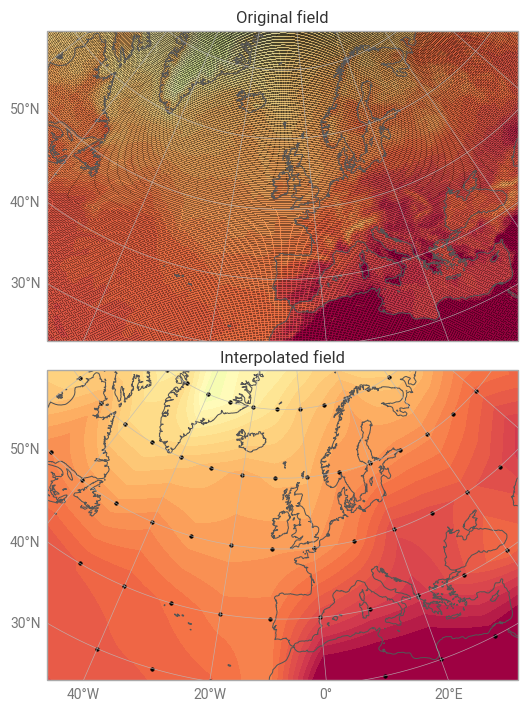

In [16]:
figure = ekp.Figure(domain="North Atlantic", rows=2, columns=1)

# the original field
subplot = figure.add_map(0, 0)
subplot.contourf(f,  auto_style=True)
subplot.grid_points(f, c="black", alpha=0.3, s=1)
subplot.title("Original field")

# the interpolated field
subplot = figure.add_map(1, 0)
subplot.contourf(f_res,  auto_style=True)
subplot.grid_points(f_res, c="black", s=25)
subplot.title("Interpolated field")

figure.coastlines()
figure.gridlines()

figure.show()

## Extra work

### Extract and plot data for specific regions

This example uses earthkit-geo's country_polygons() function to return the points describing country boundaries. We will then use that in a polytope request that will contact the ECMWF MARS server and request data for just those regions. The result will be in the covjson format, which we will convert to xarray and plot.

In [17]:
from earthkit.geo.cartography import country_polygons

domain = ["France", "Ireland"]

In [18]:
domain_polys = country_polygons(domain)

Quick polytope primer: if the below request fails because of authemtication, you may need to create your auth file by coping your ~/.ecmwfapirc file into ~/.polytopeapirc and renaming 'key' to 'user_key', and 'e-mail' to 'user_email'. See also https://confluence.ecmwf.int/display/WEBAPI/Access+MARS#AccessMARS-key for details on acquiring the ~/.ecmwfapirc file.

In [19]:
request = {
    "stream": "oper",
    "levtype": "sfc",
    "param": "2t",
    "step": "12",
    "time": "00",
    "date": "20260430",
    "type": "fc",
    "domain": "g",
    "feature" : {
        "type" : "polygon",
        "shape" : domain_polys,
    },
}

data_from_domain = ekd.from_source("polytope", "ecmwf-mars", request=request, stream=False)

2026-05-01 10:44:26 - INFO - Key read from /Users/cgr/.polytopeapirc
2026-05-01 10:44:26 - INFO - Sending request...
{'request': "date: '20260430'\n"
            'domain: g\n'
            'feature:\n'
            '  shape:\n'
            '  - - - 43.00998484961471\n'
            '      - 9.390000848028876\n'
            '    - - 42.15249197037952\n'
            '      - 9.560016310269134\n'
            '    - - 41.380006822264455\n'
            '      - 9.229752231491773\n'
            '    - - 41.58361196549443\n'
            '      - 8.775723097375362\n'
            '    - - 42.25651662858306\n'
            '      - 8.544212680707773\n'
            '    - - 42.62812185319392\n'
            '      - 8.746009148807559\n'
            '    - - 43.00998484961471\n'
            '      - 9.390000848028876\n'
            '  - - - 49.01778351500333\n'
            '      - 8.099278598674744\n'
            '    - - 48.33301911070372\n'
            '      - 7.593676385131062\n'
            '    

a03b98f0-692b-4cff-aeeb-5948215685b0.covjson:   0%|          | 0.00/403k [00:00<?, ?B/s]

In [20]:
data_from_domain_xr = data_from_domain.to_xarray()
data_from_domain_xr

<xarray.Dataset> Size: 285kB
Dimensions:    (datetimes: 1, number: 1, steps: 1, points: 7112)
Coordinates:
  * datetimes  (datetimes) <U20 80B '2026-04-30T00:00:00Z'
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 12
  * points     (points) int64 57kB 0 1 2 3 4 5 ... 7106 7107 7108 7109 7110 7111
    latitude   (points) float64 57kB 41.44 41.51 41.51 ... 54.94 55.01 55.01
    longitude  (points) float64 57kB 9.194 8.948 9.078 ... 352.5 352.3 352.5
    levelist   (points) float64 57kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    2t         (datetimes, number, steps, points) float64 57kB 293.2 ... 288.8
Attributes:
    class:          od
    Forecast date:  2026-04-30T00:00:00Z
    domain:         g
    expver:         0001
    levtype:        sfc
    step:           12
    stream:         oper
    type:           fc
    number:         0
    date:           2026-04-30T00:00:00Z

axis='', name='points', long_name='', standard_name='', units

<xarray.DataArray 'points' (points: 7112)> Size: 57kB
array([   0,    1,    2, ..., 7109, 7110, 7111], shape=(7112,))
Coordinates:
  * points     (points) int64 57kB 0 1 2 3 4 5 ... 7106 7107 7108 7109 7110 7111
    latitude   (points) float64 57kB 41.44 41.51 41.51 ... 54.94 55.01 55.01
    longitude  (points) float64 57kB 9.194 8.948 9.078 ... 352.5 352.3 352.5
    levelist   (points) float64 57kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    datetimes  <U20 80B '2026-04-30T00:00:00Z'
    number     int64 8B 0
    steps      int64 8B 12

<class 'numpy.ndarray'> (7112,)
axis='', name='points', long_name='', standard_name='', units

<xarray.DataArray 'points' (points: 7112)> Size: 57kB
array([   0,    1,    2, ..., 7109, 7110, 7111], shape=(7112,))
Coordinates:
  * points     (points) int64 57kB 0 1 2 3 4 5 ... 7106 7107 7108 7109 7110 7111
    latitude   (points) float64 57kB 41.44 41.51 41.51 ... 54.94 55.01 55.01
    l

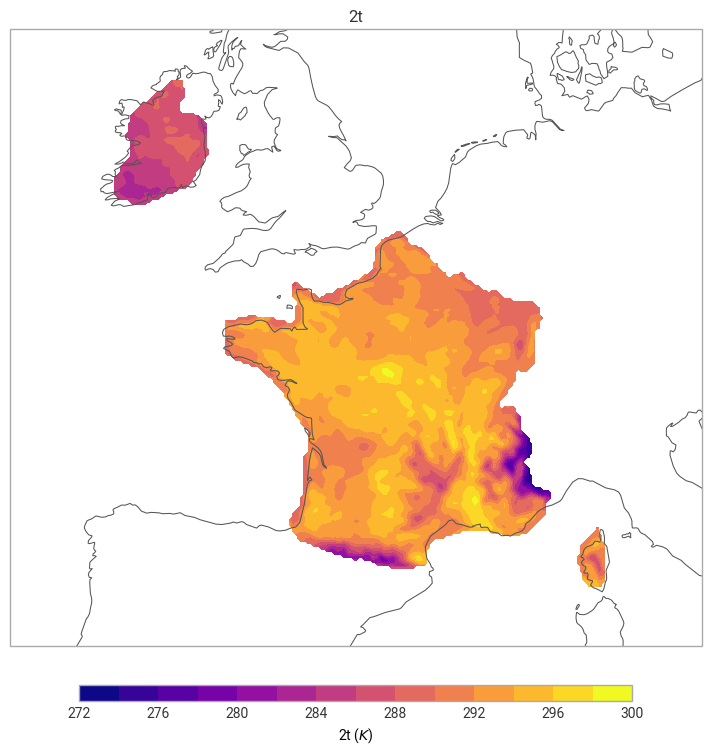

In [21]:
chart = ekp.geo.plot(data_from_domain_xr, domain=domain)
chart.title()
chart.show()

### Rotate points

This example will show how to rotate points by setting a new South pole. First, define a helper function to plot points on a globe:

In [22]:
def plot_globe(lats, lons, pole_lat, pole_lon, title=""):
    import cartopy.crs as ccrs
    import numpy as np

    antarctic_domain = ekp.geography.domains.Domain(
        [-4000000, 4000000, -4000000, 4000000],
        crs=ccrs.SouthPolarStereo(),
        name="Antarctica",
    )
        
    chart = ekp.Figure(domain=antarctic_domain, rows=1, columns=1)

    subplot = chart.add_map()

    subplot.scatter(x=lons, y=lats, edgecolors="black", z=np.arange(len(lons)), s=60)
    subplot.scatter(x=np.array([pole_lon]), marker="X", y=np.array([pole_lat]), edgecolors="red", c="red", z=np.array([pole_lon]), s=80)

    chart.land()
    chart.coastlines(color="grey")
    chart.gridlines()
    chart.title(title)
    chart.show()

`geo.rotate.rotate()` performs a spherical rotation. The rotation itself is specified by the rotated position of the south pole. In the example below it is lat=-75, lon=-20. For details of the rotate function, see https://earthkit-geo.readthedocs.io/en/latest/autoapi/earthkit/geo/rotate/rotate.html

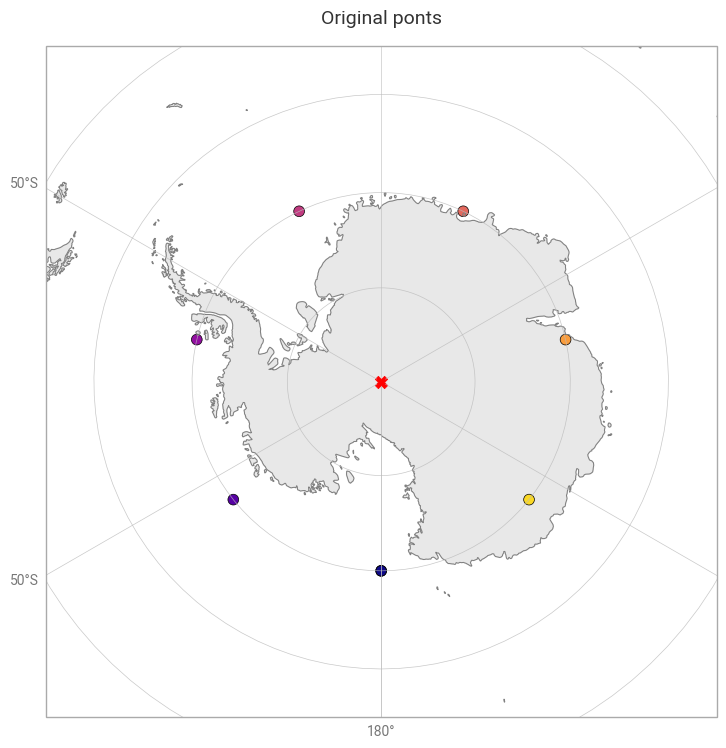

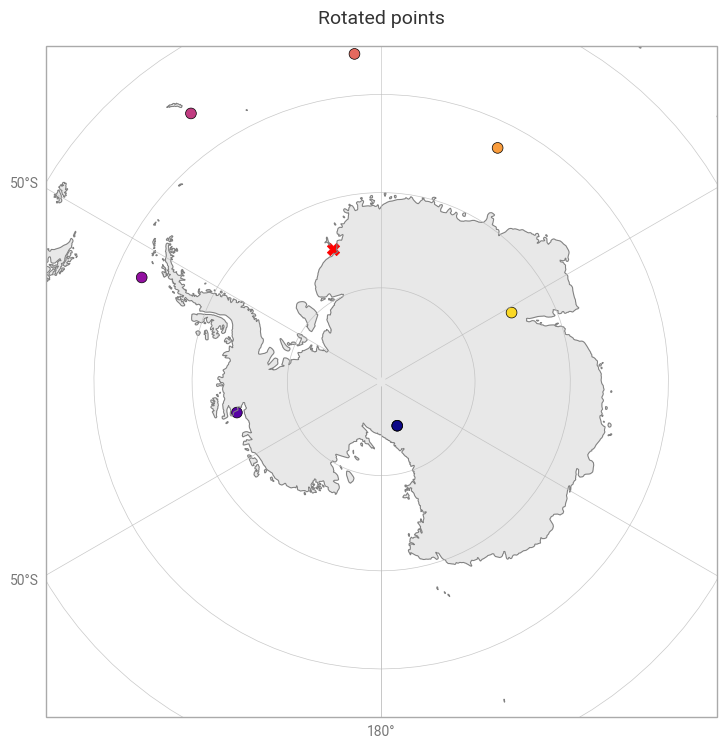

In [23]:
import numpy as np

from earthkit.geo.rotate import rotate

# new position of the south pole, this defines the rotation
original_south_pole = [-90, 0]
south_pole = [-75, -20]

# list of points on the lat=-70 latitude
lats = np.array([-70] * 8)
lons = np.linspace(-180, 180, 8)

# XX exercise perform rotation - your code here!
lats_r, lons_r = rotate(lats, lons, south_pole[0], south_pole[1])

# plot the points, red cross marks the south pole
plot_globe(lats, lons, original_south_pole[0], original_south_pole[1], title="Original ponts")
plot_globe(lats_r, lons_r, south_pole[0], south_pole[1], title="Rotated points")

### Plot grid values

Inspect the following code to see how to plot grid point values on the map

The next plot shows a smaller area and displays the grid values at each grid point. We will use the data() method, which returns arrays of latitudes, longitudes and values; this information can then be used to create value labels. And with a bit of cartopy magic, we can shift the labels to sit nicely above the points!

Since the raw data values are actually stored in Kelvin, we will also revert the shading to use Kelvin so we are seeing the 'real' data.

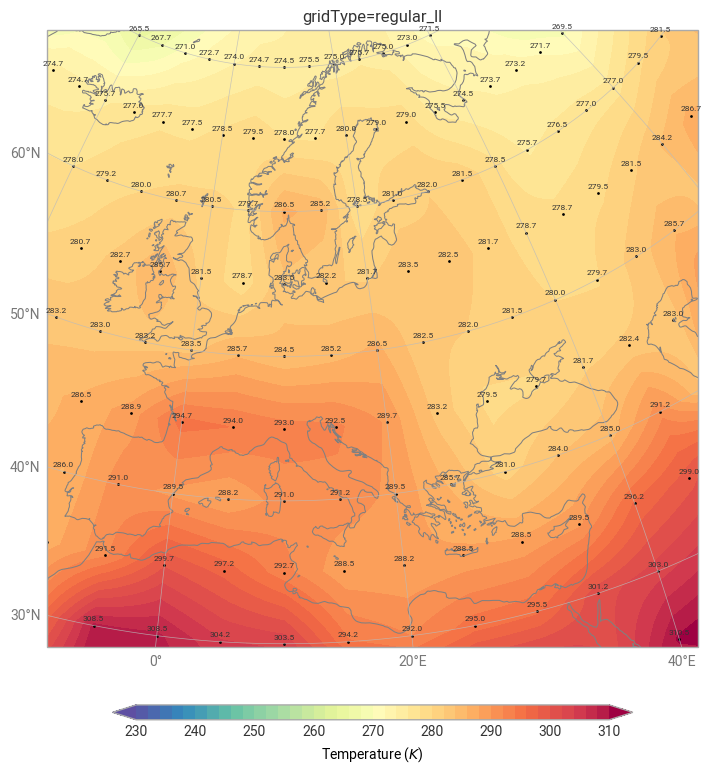

In [24]:
import cartopy.crs as ccrs

f = ds[field_index]

chart = ekp.Map(domain="Europe")
chart.contourf(f, units="kelvin", auto_style=True)
# plot the original grid points
chart.grid_points(f, c="black") #marker="+"

# generate grid values
lat, lon, vals = f.data(flatten=True)
labels = [f"{x:.1f}" for x in vals]
for i, lbs in enumerate(labels):
    chart.ax.annotate(lbs, (lon[i], lat[i]), transform=ccrs.Geodetic(), 
                      xytext=(0,5),
                      textcoords="offset pixels", 
                      annotation_clip=True, 
                      fontsize=6, horizontalalignment="center")

chart.title(f"gridType={f.geography.grid_type()}")
chart.coastlines(color="grey")
chart.gridlines()
chart.legend()

chart.show()